# kNNとRandom Forestによるクラス分類

`diabetes.csv` を使って、糖尿病かどうかを表す `Outcome` を分類します。

今回は以下を比較します。

- kNNのデフォルト設定
- kNNのハイパーパラメータチューニング後
- Random Forestのデフォルト設定
- Random Forestのハイパーパラメータチューニング後

また、学習データ内で5分割交差検証（CV）を行い、テストデータでの評価結果と比較します。

## 1. ライブラリの読み込み

データの読み込み、前処理、モデル構築、ハイパーパラメータチューニング、評価、可視化に使うライブラリを読み込みます。

In [25]:
# 数値計算をするためのライブラリを読み込みます。
import numpy as np

# 表形式のデータを扱うためのライブラリを読み込みます。
import pandas as pd

# データを学習用とテスト用に分ける道具、CV、グリッドサーチを読み込みます。
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate

# 特徴量の大きさをそろえる道具を読み込みます。
from sklearn.preprocessing import StandardScaler

# kNNで使うパイプラインを読み込みます。
from sklearn.pipeline import Pipeline

# kNN分類モデルを読み込みます。
from sklearn.neighbors import KNeighborsClassifier

# Random Forest分類モデルを読み込みます。
from sklearn.ensemble import RandomForestClassifier

# モデルの分類性能を評価する道具を読み込みます。
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, average_precision_score

# グラフを描くためのライブラリを読み込みます。
import matplotlib.pyplot as plt

from matplotlib import font_manager


## 2. CSVファイルの読み込み

`pd.read_csv()` を使ってCSVファイルを読み込み、先頭5行を表示して中身を確認します。

In [26]:
# 読み込むCSVファイルの場所を指定します。
file_path = "/Users/k-teppei/Documents/Python Seminar/diabetes.csv"

# CSVファイルを読み込んで、dfという名前の表にします。
df = pd.read_csv(file_path)

# データの先頭5行を表示して、内容を確認します。
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. データの基本情報を確認する

欠損値の有無、データ数、列数、目的変数 `Outcome` のクラス数を確認します。

`Outcome` は `0` と `1` の2値分類です。

In [27]:
# データの行数と列数を確認します。
print("データの形:", df.shape)

# 欠損値の数を確認します。
print("\n欠損値の数:")
print(df.isna().sum())

# 目的変数Outcomeのクラス数を確認します。
print("\nOutcomeのクラス数:")
print(df["Outcome"].value_counts())

# 目的変数Outcomeの割合を確認します。
print("\nOutcomeの割合:")
print(df["Outcome"].value_counts(normalize=True).round(3))

データの形: (768, 9)

欠損値の数:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Outcomeのクラス数:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcomeの割合:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


## 4. 説明変数と目的変数に分ける

`Outcome` が予測したい目的変数です。それ以外の列を、予測に使う説明変数にします。

In [28]:
# Outcome以外の列を説明変数Xにします。
X = df.drop("Outcome", axis=1)

# Outcomeを目的変数yにします。
y = df["Outcome"]

# 説明変数のデータ数と列数を確認します。
print("説明変数の形:", X.shape)

# 目的変数のデータ数を確認します。
print("目的変数の形:", y.shape)

説明変数の形: (768, 8)
目的変数の形: (768,)


## 5. 学習用データとテスト用データに分ける

データの80%を学習用、20%をテスト用に分けます。

今回は分類問題なので、`stratify=y` を指定して、学習用データとテスト用データで `Outcome` の割合が大きく変わらないようにします。

In [29]:
# データの80%を学習用、20%をテスト用に分けます。
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 学習用データの大きさを確認します。
print("学習用データ:", X_train.shape)

# テスト用データの大きさを確認します。
print("テスト用データ:", X_test.shape)

# 学習用データとテスト用データのクラス割合を確認します。
print("\n学習用データのクラス割合:")
print(y_train.value_counts(normalize=True).round(3))

print("\nテスト用データのクラス割合:")
print(y_test.value_counts(normalize=True).round(3))

学習用データ: (614, 8)
テスト用データ: (154, 8)

学習用データのクラス割合:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

テスト用データのクラス割合:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## 6. 交差検証の設定を作る

5分割交差検証を行います。

分類問題なので、各分割でクラスの割合がなるべく保たれる `StratifiedKFold` を使います。

In [30]:
# 5分割交差検証の設定を作ります。
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 評価指標をまとめて指定します。
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

## 7. 評価用の関数を作る

同じ方法で各モデルを評価できるように、CVの結果とテストデータの結果をまとめる関数を作ります。

主な評価指標は以下です。

- Accuracy: 全体でどれくらい正解したか
- Precision: 1と予測したもののうち、実際に1だった割合
- Recall: 実際に1のものを、どれくらい1と見つけられたか
- F1: PrecisionとRecallのバランス
- ROC-AUC: 0と1をどれくらい分けられているか

In [31]:
# モデルを評価して、結果を辞書として返す関数を作ります。
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, cv):
    # 学習データの中で5分割交差検証を行います。
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    # 学習データ全体を使ってモデルを学習します。
    model.fit(X_train, y_train)

    # テストデータのクラスを予測します。
    y_pred = model.predict(X_test)

    # テストデータのクラス1である確率を予測します。
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # CV結果とテスト結果をまとめます。
    result = {
        "モデル": model_name,
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "CV Precision": cv_result["test_precision"].mean(),
        "CV Recall": cv_result["test_recall"].mean(),
        "CV F1": cv_result["test_f1"].mean(),
        "CV ROC-AUC": cv_result["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_pred_proba)
    }

    return result, y_pred, y_pred_proba

## 8. デフォルト設定のkNNモデルを作る

kNNは特徴量の大きさの影響を受けやすいモデルです。

そのため、`StandardScaler` で標準化してから `KNeighborsClassifier` に渡すパイプラインを作ります。

In [32]:
# 標準化とkNNをまとめたパイプラインを作ります。
knn_default = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# デフォルト設定のkNNを評価します。
knn_default_result, knn_default_pred, knn_default_proba = evaluate_model(
    "kNN（デフォルト）",
    knn_default,
    X_train,
    y_train,
    X_test,
    y_test,
    cv
)

# 評価結果を表示します。
pd.DataFrame([knn_default_result]).round(4)

,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,kNN（デフォルト）,0.7361,0.6521,0.5424,0.5876,0.7824,0.7013,0.5833,0.5185,0.549,0.7405


## 9. kNNのハイパーパラメータをチューニングする

`GridSearchCV` を使って、kNNの主なハイパーパラメータを試します。

今回は `ROC-AUC` が高くなる組み合わせを探します。

In [33]:
# kNNで試したいハイパーパラメータの候補を指定します。
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

# GridSearchCVで、候補の中から一番良いkNNモデルを探します。
knn_grid_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    knn_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

# 学習データを使って、ハイパーパラメータを最適化します。
knn_grid_search.fit(X_train, y_train)

# 一番良かったハイパーパラメータを表示します。
print("最適なハイパーパラメータ:", knn_grid_search.best_params_)

# 交差検証での一番良いROC-AUCを表示します。
print("交差検証での最良ROC-AUC:", knn_grid_search.best_score_)

最適なハイパーパラメータ: {'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'distance'}
交差検証での最良ROC-AUC: 0.8233582502768548


## 10. kNNのチューニング結果を表で確認する

どのハイパーパラメータの組み合わせが良かったかを、ROC-AUCが高い順に表示します。

In [34]:
# GridSearchCVの結果を表に変換します。
knn_grid_results_df = pd.DataFrame(knn_grid_search.cv_results_)

# 見たい列だけを取り出して、ROC-AUCが高い順に並べます。
knn_grid_results_df = knn_grid_results_df[[
    "param_model__n_neighbors",
    "param_model__weights",
    "param_model__p",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

# 上位10件の結果を表示します。
knn_grid_results_df.head(10)

,param_model__n_neighbors,param_model__weights,param_model__p,mean_test_score,rank_test_score
25,21,distance,1,0.823358,1
24,21,uniform,1,0.822348,2
27,21,distance,2,0.818913,3
23,15,distance,2,0.818212,4
21,15,distance,1,0.815601,5
26,21,uniform,2,0.815382,6
19,11,distance,2,0.815063,7
22,15,uniform,2,0.813263,8
20,15,uniform,1,0.811749,9
18,11,uniform,2,0.811311,10


## 11. チューニング後のkNNを評価する

`GridSearchCV` で選ばれた最良モデルを使って、CV結果とテストデータの結果を確認します。

In [35]:
# 一番良かったkNNモデルを取り出します。
knn_tuned = knn_grid_search.best_estimator_

# チューニング後のkNNを評価します。
knn_tuned_result, knn_tuned_pred, knn_tuned_proba = evaluate_model(
    "kNN（チューニング後）",
    knn_tuned,
    X_train,
    y_train,
    X_test,
    y_test,
    cv
)

# 評価結果を表示します。
pd.DataFrame([knn_tuned_result]).round(4)

,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,kNN（チューニング後）,0.7492,0.7374,0.4443,0.5521,0.8234,0.7532,0.6818,0.5556,0.6122,0.8055


## 12. デフォルト設定のRandom Forestモデルを作る

Random Forestは決定木をたくさん作って分類するモデルです。

特徴量のスケールの影響を受けにくいため、ここでは標準化を行わずに使います。

In [36]:
# デフォルト設定のRandom Forestモデルを作ります。
rf_default = RandomForestClassifier(random_state=42)

# デフォルト設定のRandom Forestを評価します。
rf_default_result, rf_default_pred, rf_default_proba = evaluate_model(
    "Random Forest（デフォルト）",
    rf_default,
    X_train,
    y_train,
    X_test,
    y_test,
    cv
)

# 評価結果を表示します。
pd.DataFrame([rf_default_result]).round(4)

,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest（デフォルト）,0.7655,0.7018,0.5796,0.6328,0.811,0.7727,0.7111,0.5926,0.6465,0.8148


## 13. Random Forestのハイパーパラメータをチューニングする

`GridSearchCV` を使って、Random Forestの主なハイパーパラメータを試します。

候補を増やしすぎると計算時間が長くなるため、授業で実行しやすい範囲にしています。

In [37]:
# Random Forestで試したいハイパーパラメータの候補を指定します。
rf_param_grid = {
    "n_estimators": [100],
    "max_depth": [None, 3, 5, 7],
    "min_samples_leaf": [1, 3],
    "max_features": ["sqrt"]
}

# GridSearchCVで、候補の中から一番良いRandom Forestモデルを探します。
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1
)

# 学習データを使って、ハイパーパラメータを最適化します。
rf_grid_search.fit(X_train, y_train)

# 一番良かったハイパーパラメータを表示します。
print("最適なハイパーパラメータ:", rf_grid_search.best_params_)

# 交差検証での一番良いROC-AUCを表示します。
print("交差検証での最良ROC-AUC:", rf_grid_search.best_score_)

最適なハイパーパラメータ: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
交差検証での最良ROC-AUC: 0.8297978959025469


## 14. Random Forestのチューニング結果を表で確認する

どのハイパーパラメータの組み合わせが良かったかを、ROC-AUCが高い順に表示します。

In [38]:
# GridSearchCVの結果を表に変換します。
rf_grid_results_df = pd.DataFrame(rf_grid_search.cv_results_)

# 見たい列だけを取り出して、ROC-AUCが高い順に並べます。
rf_grid_results_df = rf_grid_results_df[[
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "param_max_features",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

# 上位10件の結果を表示します。
rf_grid_results_df.head(10)

,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_score,rank_test_score
4,100,5,1,sqrt,0.829798,1
5,100,5,3,sqrt,0.829282,2
2,100,3,1,sqrt,0.829125,3
3,100,3,3,sqrt,0.829073,4
7,100,7,3,sqrt,0.826866,5
1,100,None,3,sqrt,0.823639,6
6,100,7,1,sqrt,0.821568,7
0,100,None,1,sqrt,0.811001,8


## 15. チューニング後のRandom Forestを評価する

`GridSearchCV` で選ばれた最良モデルを使って、CV結果とテストデータの結果を確認します。

In [39]:
# 一番良かったRandom Forestモデルを取り出します。
rf_tuned = rf_grid_search.best_estimator_

# チューニング後のRandom Forestを評価します。
rf_tuned_result, rf_tuned_pred, rf_tuned_proba = evaluate_model(
    "Random Forest（チューニング後）",
    rf_tuned,
    X_train,
    y_train,
    X_test,
    y_test,
    cv
)

# 評価結果を表示します。
pd.DataFrame([rf_tuned_result]).round(4)

,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Random Forest（チューニング後）,0.7704,0.7347,0.5472,0.6234,0.8298,0.7273,0.6429,0.5,0.5625,0.8093


## 16. 4つのモデルを比較する

デフォルト設定とハイパーパラメータチューニング後の結果を、1つの表にまとめて比較します。

CVの結果は学習データ内での交差検証、Testの結果は最後に残しておいたテストデータでの評価です。

In [40]:
# 4つのモデルの評価結果を1つの表にまとめます。
comparison_df = pd.DataFrame([
    knn_default_result,
    knn_tuned_result,
    rf_default_result,
    rf_tuned_result
])

# 小数第4位まで表示します。
comparison_df.round(4)

,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,kNN（デフォルト）,0.7361,0.6521,0.5424,0.5876,0.7824,0.7013,0.5833,0.5185,0.5490,0.7405
1,kNN（チューニング後）,0.7492,0.7374,0.4443,0.5521,0.8234,0.7532,0.6818,0.5556,0.6122,0.8055
2,Random Forest（デフォルト）,0.7655,0.7018,0.5796,0.6328,0.8110,0.7727,0.7111,0.5926,0.6465,0.8148
3,Random Forest（チューニング後）,0.7704,0.7347,0.5472,0.6234,0.8298,0.7273,0.6429,0.5000,0.5625,0.8093


## 17. 比較結果をグラフで確認する

テストデータでの `Accuracy`、`F1`、`ROC-AUC` を棒グラフで比較します。

/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_50336/827058062.py:14: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_50336/827058062.py:14: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_50336/827058062.py:14: UserWarning: Glyph 12501 (\N{KATAKANA LETTER HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_50336/827058062.py:14: UserWarning: Glyph 12457 (\N{KATAKANA LETTER SMALL O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipykernel_50336/827058062.py:14: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f0/n07b6_997s969kfj2djm5vz80000gr/T/ipy

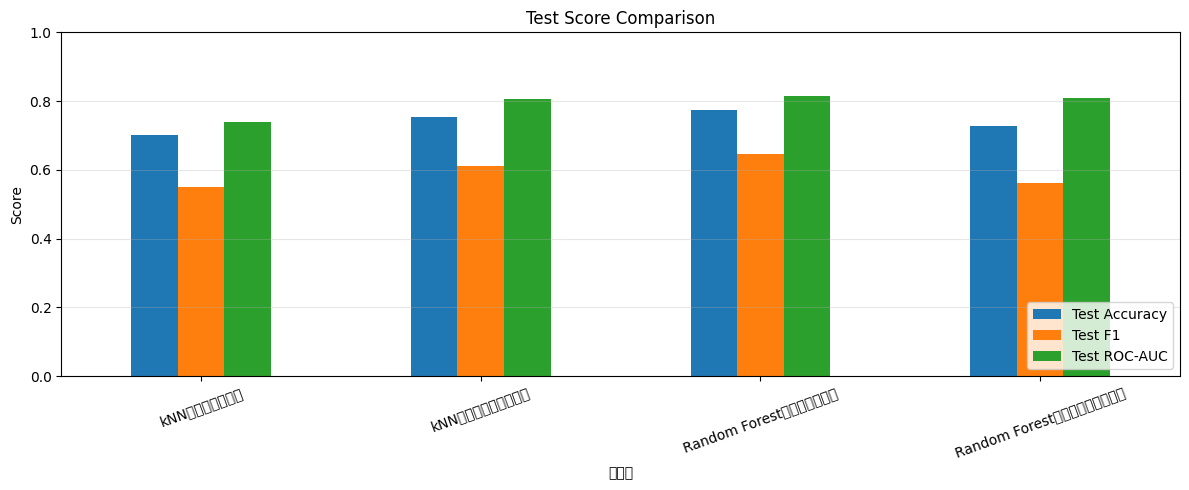

In [41]:
# グラフで比較したい評価指標を指定します。
plot_columns = ["Test Accuracy", "Test F1", "Test ROC-AUC"]

# 比較用の表を作ります。
plot_df = comparison_df.set_index("モデル")[plot_columns]

# 棒グラフを描きます。
ax = plot_df.plot(kind="bar", figsize=(12, 5), rot=20)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Test Score Comparison")
ax.grid(True, axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 18. ROC曲線を確認する

ROC曲線は、分類のしきい値を動かしたときの `False Positive Rate` と `True Positive Rate` の関係を表します。

曲線が左上に近く、ROC-AUCが1に近いほど、0と1をうまく分けられていると考えられます。

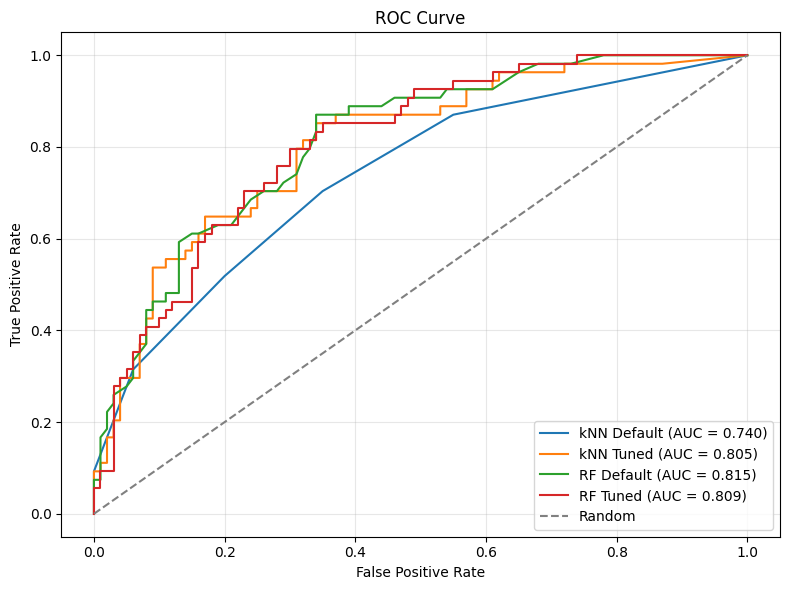

In [42]:
# 各モデルのクラス1である予測確率をまとめます。
proba_dict = {
    "kNN Default": knn_default_proba,
    "kNN Tuned": knn_tuned_proba,
    "RF Default": rf_default_proba,
    "RF Tuned": rf_tuned_proba
}

# ROC曲線を描きます。
plt.figure(figsize=(8, 6))

for model_name, y_proba in proba_dict.items():
    # False Positive Rate、True Positive Rate、しきい値を計算します。
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    # ROC-AUCを計算します。
    auc_score = roc_auc_score(y_test, y_proba)

    # モデルごとのROC曲線を描きます。
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

# ランダムに予測した場合の基準線を描きます。
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")

# グラフのタイトルと軸ラベルを設定します。
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 19. PR曲線を確認する

PR曲線は、分類のしきい値を動かしたときの `Precision` と `Recall` の関係を表します。

陽性クラスである `Outcome=1` をどれくらいうまく見つけられているかを確認しやすいグラフです。

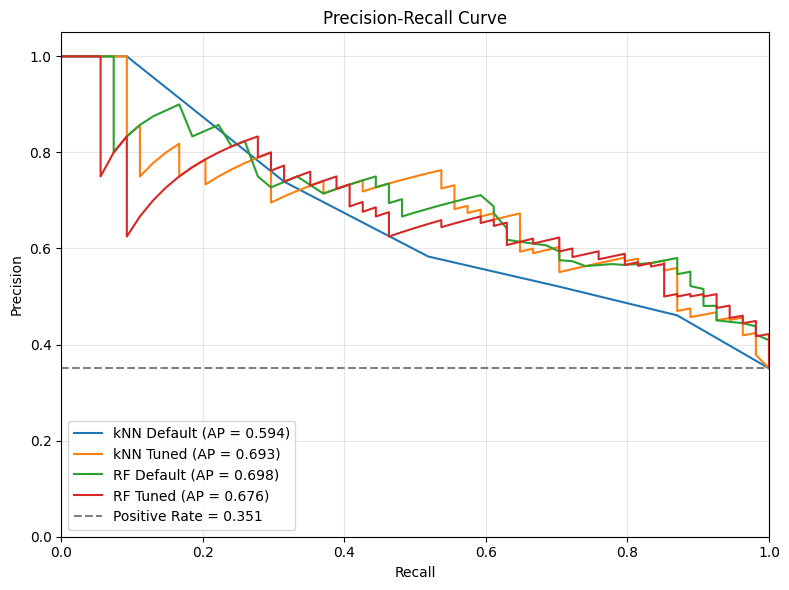

In [43]:
# PR曲線を描きます。
plt.figure(figsize=(8, 6))

for model_name, y_proba in proba_dict.items():
    # Precision、Recall、しきい値を計算します。
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    # Average Precisionを計算します。
    ap_score = average_precision_score(y_test, y_proba)

    # モデルごとのPR曲線を描きます。
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_score:.3f})")

# 陽性クラスの割合を基準線として描きます。
positive_rate = y_test.mean()
plt.hlines(positive_rate, 0, 1, color="gray", linestyle="--", label=f"Positive Rate = {positive_rate:.3f}")

# グラフのタイトルと軸ラベルを設定します。
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.05)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 20. 混同行列で予測結果を確認する

混同行列を使うと、実際のクラスと予測したクラスの組み合わせを確認できます。

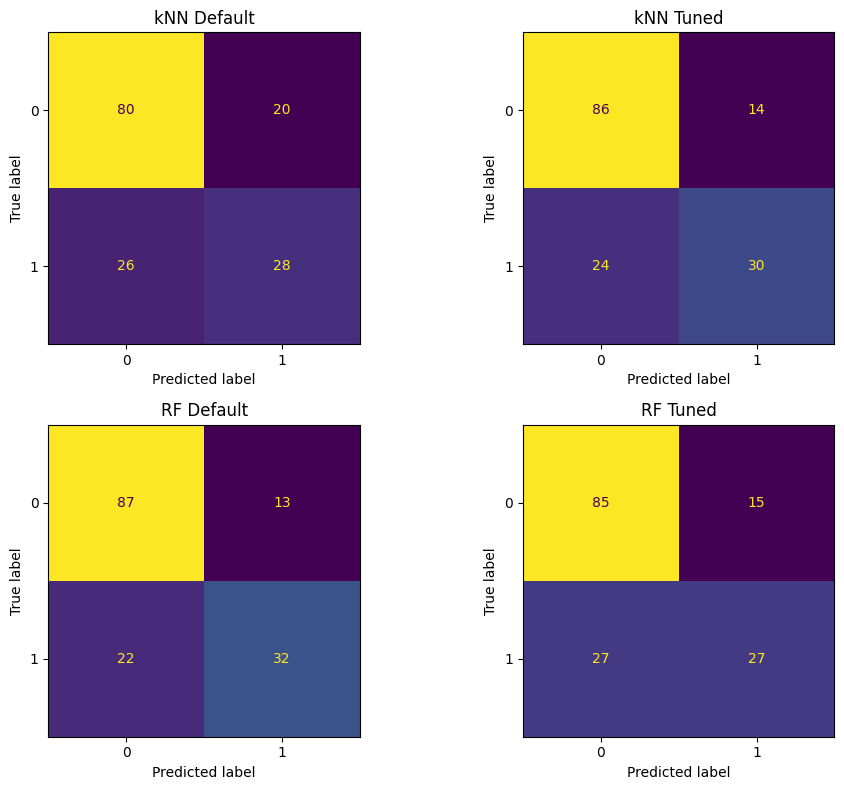

In [44]:
# 各モデルの予測結果をまとめます。
prediction_dict = {
    "kNN Default": knn_default_pred,
    "kNN Tuned": knn_tuned_pred,
    "RF Default": rf_default_pred,
    "RF Tuned": rf_tuned_pred
}

# 4つの混同行列を並べて表示します。
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (model_name, y_pred) in zip(axes, prediction_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## 21. Random Forestの特徴量重要度を確認する

Random Forestでは、どの特徴量が分類に効いていたかを `feature_importances_` で確認できます。

In [45]:
# チューニング後のRandom Forestから特徴量重要度を取り出します。
feature_importance_df = pd.DataFrame({
    "特徴量": X.columns,
    "重要度": rf_tuned.feature_importances_
})

# 重要度が高い順に並べます。
feature_importance_df = feature_importance_df.sort_values("重要度", ascending=False)

# 特徴量重要度を表示します。
feature_importance_df

,特徴量,重要度
1,Glucose,0.385987
5,BMI,0.172660
7,Age,0.116051
6,DiabetesPedigreeFunction,0.085799
0,Pregnancies,0.071270
4,Insulin,0.068597
2,BloodPressure,0.052664
3,SkinThickness,0.046973


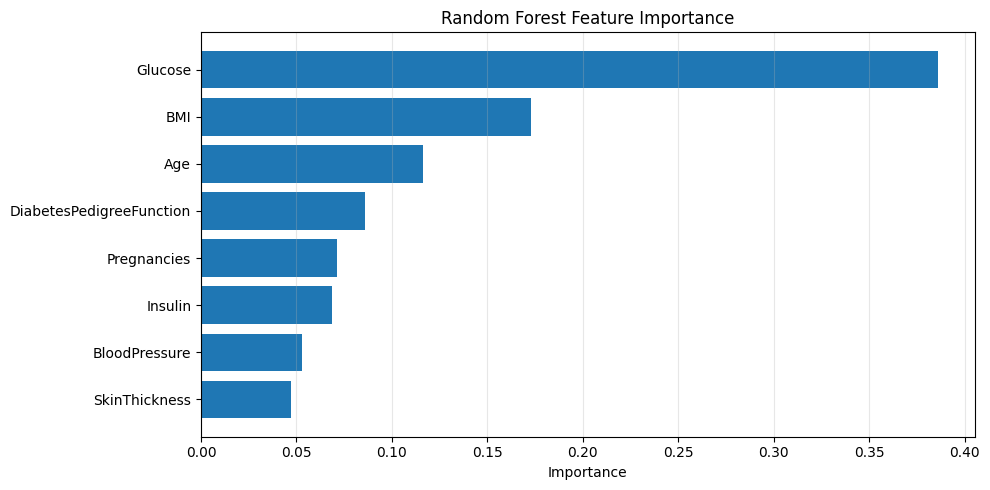

In [46]:
# 特徴量重要度を棒グラフで表示します。
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df["特徴量"], feature_importance_df["重要度"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 22. まとめ

このデータでは、デフォルト設定とチューニング後の結果を比較すると、評価指標によって良いモデルが変わることがあります。

特に医療系の分類では、単にAccuracyだけを見るのではなく、糖尿病の人を見逃さないためのRecallや、全体的な分類性能を見るROC-AUCも確認することが重要です。

In [47]:
# ROC-AUCが最も高いモデルを確認します。
best_model_by_auc = comparison_df.sort_values("Test ROC-AUC", ascending=False).iloc[0]

print("Test ROC-AUCが最も高いモデル:", best_model_by_auc["モデル"])
print("Test ROC-AUC:", round(best_model_by_auc["Test ROC-AUC"], 4))

# 比較表を再表示します。
comparison_df.round(4)

Test ROC-AUCが最も高いモデル: Random Forest（デフォルト）
Test ROC-AUC: 0.8148


,モデル,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,kNN（デフォルト）,0.7361,0.6521,0.5424,0.5876,0.7824,0.7013,0.5833,0.5185,0.5490,0.7405
1,kNN（チューニング後）,0.7492,0.7374,0.4443,0.5521,0.8234,0.7532,0.6818,0.5556,0.6122,0.8055
2,Random Forest（デフォルト）,0.7655,0.7018,0.5796,0.6328,0.8110,0.7727,0.7111,0.5926,0.6465,0.8148
3,Random Forest（チューニング後）,0.7704,0.7347,0.5472,0.6234,0.8298,0.7273,0.6429,0.5000,0.5625,0.8093
